<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Depuración de datos (Data Wrangling)


Tiempo estimado: **30** minutos
    

## Objetivos

Al finalizar este laboratorio serás capaz de:

* Manejar los valores faltantes
* Corregir el formato de los datos
* Estandarizar y normalizar los datos

<h2>Contenido</h2>

<div class="alert alert-block alert-info" style="margin-top: 20px">
<ul>
    <li><a href="#Identify-and-handle-missing-values">Identificar y manejar los valores faltantes</a>
        <ul>
            <li><a href="#Identify-missing-values">Identificar los valores faltantes</a></li>
            <li><a href="#Deal-with-missing-data">Manejar los valores faltantes</a></li>
            <li><a href="#Correct-data-format">Corregir el formato de los datos</a></li>
        </ul>
    </li>
    <li><a href="#Data-Standardization">Estandarización de datos</a></li>
    <li><a href="#Data-Normalization">Normalización de datos (centrado/escalado)</a></li>
    <li><a href="#Binning">Intervalos (binning)</a></li>
    <li><a href="#Indicator-Variable">Variable indicadora</a></li>
</ul>
    
</div>
 
<hr>

<h2>¿Cuál es el propósito de la depuración de datos?</h2>

La depuración de datos (data wrangling) sirve para convertir los datos de un formato inicial a un formato que resulte más adecuado para el análisis.

<h3>Importar los datos</h3>
<p>
Puedes encontrar el "Automobile Dataset" en el siguiente enlace: <a href="https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data">https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data</a>. 
Usarás este conjunto de datos a lo largo de todo el curso.
</p>

<h4>Importar pandas</h4>

In [1]:
# instalar una versión específica de las bibliotecas usadas en el laboratorio
#! mamba install pandas==1.3.3
#! mamba install numpy=1.21.2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<h2>Leer el conjunto de datos desde la URL y agregar los encabezados correspondientes</h2>

Las funciones siguientes descargan el conjunto de datos en tu navegador:

In [3]:
# Descarga un archivo desde una URL y lo guarda en disco.
# Funciona igual en JupyterLite (kernel del navegador) y en un kernel local
# (Anaconda, VS Code, etc.). Mantiene la firma asincrona, de modo que la celda
# que hace "await download(file_path, 'auto.csv')" sigue funcionando igual.

try:
    # Kernel del navegador: pyodide solo existe dentro de JupyterLite.
    from pyodide.http import pyfetch

    async def download(url, filename):
        response = await pyfetch(url)
        if response.status == 200:
            with open(filename, "wb") as f:
                f.write(await response.bytes())
        else:
            raise Exception(f"Download failed with status {response.status}")

except ModuleNotFoundError:
    # Kernel local (CPython): usamos la libreria estandar, sin pyodide.
    import asyncio
    from urllib.request import Request, urlopen

    def _descargar(url, filename):
        peticion = Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urlopen(peticion) as respuesta, open(filename, "wb") as f:
            f.write(respuesta.read())

    async def download(url, filename):
        # en un hilo aparte para no bloquear el bucle de eventos del cuaderno
        await asyncio.to_thread(_descargar, url, filename)

Primero, asigna la URL del conjunto de datos a "filepath". 

In [4]:
file_path="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv"

Para obtener el conjunto de datos, usa la función download() definida arriba:

In [5]:
await download(file_path, "usedcars.csv")
file_name="usedcars.csv"

Luego, crea una lista de Python <b>headers</b> con los nombres de los encabezados.

In [6]:
headers = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-of-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-of-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]

Usa el método <b>read_csv()</b> de Pandas para cargar los datos desde la dirección web. Asigna al parámetro "names" la lista de Python "headers".

In [7]:
df = pd.read_csv(file_name, names = headers)

> Nota: esta versión del laboratorio funciona en JupyterLite, que exige descargar el conjunto de datos a la interfaz. Si trabajas con la versión descargada de este cuaderno en tu máquina local (Jupyter Anaconda), puedes simplemente **omitir los pasos anteriores** y usar la URL directamente en la función `pandas.read_csv()`. Puedes descomentar y ejecutar las instrucciones de la celda de abajo.

In [ ]:
#filepath = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv"
#df = pd.read_csv(filepath, header=None, names=headers)    # usa la misma lista de encabezados definida arriba

  Usa el método <b>head()</b> para mostrar las primeras cinco filas del dataframe. 

In [8]:
# Para ver cómo es el conjunto de datos, usamos el método head().
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


Como puedes ver, en el dataframe aparecen varios signos de interrogación; esos valores faltantes pueden dificultar el análisis posterior. 
<div>Entonces, ¿cómo identificamos todos esos valores faltantes y cómo los tratamos?</div> 


<b>¿Cómo trabajar con datos faltantes?</b>

Pasos para trabajar con datos faltantes:
<ol>
    <li>Identificar los datos faltantes</li>
    <li>Tratar los datos faltantes</li>
    <li>Corregir el formato de los datos</li>
</ol>

# Identificar y manejar los valores faltantes


### Identificar los valores faltantes
<h4>Convertir "?" a NaN</h4>
En el conjunto de datos de automóviles, los datos faltantes aparecen como el signo de interrogación "?".
Reemplazamos "?" por NaN (Not a Number), el marcador de valor faltante por defecto de Python, por razones de velocidad y comodidad de cálculo. Usa la función: 
 <pre>.replace(A, B, inplace = True) </pre>
para reemplazar A por B.

In [9]:
import numpy as np

# reemplazar "?" por NaN
df.replace("?", np.nan, inplace = True)
df.head(5)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


<h4>Evaluar los datos faltantes</h4>

Los valores faltantes se convierten automáticamente. Usa las funciones siguientes para identificarlos. Puedes usar dos métodos para detectar datos faltantes:
<ol>
    <li><b>.isnull()</b></li>
    <li><b>.notnull()</b></li>
</ol>
El resultado es un valor booleano que indica si el valor pasado como argumento es, en efecto, un dato faltante.

In [10]:
missing_data = df.isnull()
missing_data.head(5)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


"True" significa que el valor es un dato faltante, mientras que "False" significa que no lo es.

<h4>Contar los valores faltantes de cada columna</h4>
<p>
Con un bucle for en Python puedes averiguar rápidamente cuántos valores faltantes hay en cada columna. Como se mencionó antes, "True" representa un valor faltante y "False" un valor presente en el conjunto de datos. Dentro del bucle, el método ".value_counts()" cuenta cuántos valores son "True". 
</p>

In [11]:
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")    

symboling
symboling
False    205
Name: count, dtype: int64

normalized-losses
normalized-losses
False    164
True      41
Name: count, dtype: int64

make
make
False    205
Name: count, dtype: int64

fuel-type
fuel-type
False    205
Name: count, dtype: int64

aspiration
aspiration
False    205
Name: count, dtype: int64

num-of-doors
num-of-doors
False    203
True       2
Name: count, dtype: int64

body-style
body-style
False    205
Name: count, dtype: int64

drive-wheels
drive-wheels
False    205
Name: count, dtype: int64

engine-location
engine-location
False    205
Name: count, dtype: int64

wheel-base
wheel-base
False    205
Name: count, dtype: int64

length
length
False    205
Name: count, dtype: int64

width
width
False    205
Name: count, dtype: int64

height
height
False    205
Name: count, dtype: int64

curb-weight
curb-weight
False    205
Name: count, dtype: int64

engine-type
engine-type
False    205
Name: count, dtype: int64

num-of-cylinders
num-of-cylinders
False    205
Nam

Según el resumen anterior, cada columna tiene 205 filas de datos y siete columnas presentan datos faltantes:
<ol>
    <li>"normalized-losses": 41 datos faltantes</li>
    <li>"num-of-doors": 2 datos faltantes</li>
    <li>"bore": 4 datos faltantes</li>
    <li>"stroke" : 4 datos faltantes</li>
    <li>"horsepower": 2 datos faltantes</li>
    <li>"peak-rpm": 2 datos faltantes</li>
    <li>"price": 4 datos faltantes</li>
</ol>

### Tratar los datos faltantes
<b>¿Cómo deberías tratar los datos faltantes?</b>

<ol>
    <li>Eliminar datos<br>
        a. Eliminar la fila completa<br>
        b. Eliminar la columna completa
    </li>
    <li>Reemplazar datos<br>
        a. Reemplazar por la media<br>
        b. Reemplazar por la frecuencia<br>
        c. Reemplazar según otras funciones
    </li>
</ol>

Solo deberías eliminar columnas completas si la mayoría de sus entradas están vacías. En este conjunto de datos, ninguna columna está lo bastante vacía como para eliminarla por completo.
Tienes cierta libertad para elegir el método de reemplazo; sin embargo, algunos métodos resultan más razonables que otros. Aplica cada método a distintas columnas:

<b>Reemplazar por la media:</b>
<ul>
    <li>"normalized-losses": 41 datos faltantes, reemplazar por la media</li>
    <li>"stroke": 4 datos faltantes, reemplazar por la media</li>
    <li>"bore": 4 datos faltantes, reemplazar por la media</li>
    <li>"horsepower": 2 datos faltantes, reemplazar por la media</li>
    <li>"peak-rpm": 2 datos faltantes, reemplazar por la media</li>
</ul>

<b>Reemplazar por la frecuencia:</b>
<ul>
    <li>"num-of-doors": 2 datos faltantes, reemplazar por "four". 
        <ul>
            <li>Razón: el 84% de los sedanes son de cuatro puertas. Como cuatro puertas es lo más frecuente, es lo más probable que ocurra</li>
        </ul>
    </li>
</ul>

<b>Eliminar la fila completa:</b>
<ul>
    <li>"price": 4 datos faltantes, simplemente eliminar la fila completa
        <ul>
            <li>Razón: quieres predecir el precio. No puedes usar para la predicción una entrada sin dato de precio; por lo tanto, cualquier fila sin precio no te sirve.</li>
        </ul>
    </li>
</ul>

<h4>Calcular el valor medio de la columna "normalized-losses" </h4>

In [15]:
avg_norm_loss = df["normalized-losses"].astype("float").mean(axis=0)
print("Promedio de normalized-losses:", avg_norm_loss)

Promedio de normalized-losses: 122.0


<h4>Reemplazar "NaN" por el valor medio en la columna "normalized-losses"</h4>

In [16]:
df["normalized-losses"] = df["normalized-losses"].replace(np.nan, avg_norm_loss)

<h4>Calcular el valor medio de la columna "bore"</h4>

In [17]:
avg_bore=df['bore'].astype('float').mean(axis=0)
print("Promedio de bore:", avg_bore)

Promedio de bore: 3.3297512437810943


<h4>Reemplazar "NaN" por el valor medio en la columna "bore"</h4>

In [18]:
df["bore"] = df["bore"].replace(np.nan, avg_bore)

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Pregunta #1: </h1>

<b>Con base en el ejemplo anterior, reemplaza los NaN de la columna "stroke" por el valor medio.</b>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar


<details><summary>Haz clic aquí para ver la solución</summary>

```python
# calcular el valor medio de la columna "stroke"
avg_stroke = df["stroke"].astype("float").mean(axis=0)
print("Promedio de stroke:", avg_stroke)

# reemplazar los NaN por el valor medio en la columna "stroke"
df["stroke"] = df["stroke"].replace(np.nan, avg_stroke)
```

</details>

<h4>Calcular el valor medio de la columna "horsepower"</h4>

In [22]:
avg_horsepower = df['horsepower'].astype('float').mean(axis=0)
print("Promedio de horsepower:", avg_horsepower)

Promedio de horsepower: 104.25615763546799


<h4>Reemplazar "NaN" por el valor medio en la columna "horsepower"</h4>

In [23]:
df['horsepower'] = df['horsepower'].replace(np.nan, avg_horsepower)

<h4>Calcular el valor medio de la columna "peak-rpm"</h4>

In [24]:
avg_peakrpm=df['peak-rpm'].astype('float').mean(axis=0)
print("Promedio de peak rpm:", avg_peakrpm)

Promedio de peak rpm: 5125.369458128079


<h4>Reemplazar "NaN" por el valor medio en la columna "peak-rpm"</h4>

In [25]:
df['peak-rpm'] = df['peak-rpm'].replace(np.nan, avg_peakrpm)

Para ver qué valores hay en una columna determinada podemos usar el método ".value_counts()":

In [26]:
df['num-of-doors'].value_counts()

num-of-doors
four    114
two      89
Name: count, dtype: int64

Puedes ver que cuatro puertas es el tipo más común. También podemos usar el método ".idxmax()" para calcular automáticamente el tipo más frecuente:

In [27]:
df['num-of-doors'].value_counts().idxmax()

'four'

El procedimiento de reemplazo es muy similar a lo que ya viste antes:

In [28]:
# reemplazar los valores faltantes de 'num-of-doors' por el más frecuente 
df["num-of-doors"] = df["num-of-doors"].replace(np.nan, "four")

Por último, elimina todas las filas que no tienen dato de precio:

In [29]:
# eliminar la fila completa cuando hay NaN en la columna "price"
df.dropna(subset=["price"], axis=0, inplace=True)

# reiniciar el índice, porque se eliminaron cuatro filas
df.reset_index(drop=True, inplace=True)

In [30]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,3.255423,9.0,111,5000,21,27,13495
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,3.255423,9.0,111,5000,21,27,16500
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.255423,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.255423,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.255423,8.0,115,5500,18,22,17450


<b>¡Bien!</b> Ahora tienes un conjunto de datos sin valores faltantes.

### Corregir el formato de los datos
<b>¡Ya casi terminamos!</b>
<p>El último paso de la limpieza de datos consiste en verificar y asegurar que todos los datos estén en el formato correcto (int, float, texto u otro).</p>

En Pandas se usa:
<p><b>.dtypes</b> para consultar el tipo de dato</p>
<p><b>.astype()</b> para cambiar el tipo de dato</p>

<h4>Listemos los tipos de datos de cada columna</h4>

In [31]:
df.dtypes

symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke               float64
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object

<p>Como puedes ver arriba, algunas columnas no tienen el tipo de dato correcto. Las variables numéricas deberían ser de tipo 'float' o 'int', y las variables con cadenas, como las categorías, deberían ser de tipo 'object'. Por ejemplo, los valores numéricos 'bore' y 'stroke' describen los motores, así que esperarías que fueran de tipo 'float' o 'int'; sin embargo, aparecen como tipo 'object'. Debes convertir los tipos de datos al formato adecuado en cada columna usando el método "astype()".</p> 

<h4>Convertir los tipos de datos al formato adecuado</h4>

In [32]:
df[["bore", "stroke"]] = df[["bore", "stroke"]].astype("float")
df[["normalized-losses"]] = df[["normalized-losses"]].astype("int")
df[["price"]] = df[["price"]].astype("float")
df[["peak-rpm"]] = df[["peak-rpm"]].astype("float")

<h4>Listemos las columnas después de la conversión</h4>

In [33]:
df.dtypes

symboling              int64
normalized-losses      int64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower            object
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object

<b>¡Excelente!</b>

Ahora tienes por fin el conjunto de datos depurado, sin valores faltantes y con todos los datos en su formato adecuado.

## Estandarización de datos
<p>
Normalmente los datos se recogen de distintas entidades y en formatos diferentes.
(La estandarización de datos también es el nombre de un tipo particular de normalización en la que se resta la media y se divide por la desviación estándar.)
</p>
    
<b>¿Qué es estandarizar?</b>
<p>La estandarización es el proceso de transformar los datos a un formato común, lo que permite al analista hacer comparaciones significativas.
</p>

<b>Ejemplo</b>
<p>Transformar mpg a L/100km:</p>
<p>En tu conjunto de datos, las columnas de consumo de combustible "city-mpg" y "highway-mpg" están expresadas en mpg (millas por galón). Supón que desarrollas una aplicación para un país que maneja el consumo en L/100km.</p>
<p>Necesitarás aplicar una <b>transformación de datos</b> para pasar mpg a L/100km.</p>

<p>Usa esta fórmula para la conversión de unidades:<p>
L/100km = 235 / mpg
<p>Puedes hacer muchas operaciones matemáticas directamente con Pandas.</p>

In [34]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,3.255423,9.0,111,5000.0,21,27,13495.0
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,3.255423,9.0,111,5000.0,21,27,16500.0
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.255423,9.0,154,5000.0,19,26,16500.0
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.255423,10.0,102,5500.0,24,30,13950.0
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.255423,8.0,115,5500.0,18,22,17450.0


In [35]:
# convertir mpg a L/100km con una operación matemática (235 dividido por mpg)
df['city-L/100km'] = 235/df["city-mpg"]

# revisar los datos transformados 
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,3.255423,9.0,111,5000.0,21,27,13495.0,11.190476
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,3.255423,9.0,111,5000.0,21,27,16500.0,11.190476
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.255423,9.0,154,5000.0,19,26,16500.0,12.368421
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.255423,10.0,102,5500.0,24,30,13950.0,9.791667
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.255423,8.0,115,5500.0,18,22,17450.0,13.055556


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Pregunta #2: </h1>

<b>Siguiendo el ejemplo anterior, transforma mpg a L/100km en la columna "highway-mpg" y cambia el nombre de la columna a "highway-L/100km".</b>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar


<details><summary>Haz clic aquí para ver la solución</summary>

```python
# transformar mpg a L/100km con una operación matemática (235 dividido por mpg)
df["highway-mpg"] = 235/df["highway-mpg"]

# cambiar el nombre de la columna de "highway-mpg" a "highway-L/100km"
df.rename(columns={'highway-mpg':'highway-L/100km'}, inplace=True)

# revisar los datos transformados 
df.head()
```

</details>

## Normalización de datos

<b>¿Para qué normalizar?</b>
<p>La normalización es el proceso de transformar los valores de varias variables a un rango similar. Las normalizaciones típicas incluyen 
<ol>
    <li>escalar la variable para que su promedio sea 0</li>
    <li>escalar la variable para que su varianza sea 1</li> 
    <li>escalar la variable para que sus valores vayan de 0 a 1</li>
</ol>
</p>

<b>Ejemplo</b>
<p>Para demostrar la normalización, supongamos que quieres escalar las columnas "length", "width" y "height".</p>
<p><b>Meta:</b> normalizar esas variables para que sus valores vayan de 0 a 1</p>
<p><b>Enfoque:</b> reemplazar el valor original por (valor original)/(valor máximo)</p>

In [ ]:
# reemplazar (valor original) por (valor original)/(valor máximo)
df['length'] = df['length']/df['length'].max()
df['width'] = df['width']/df['width'].max()

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Pregunta #3: </h1>

<b>Siguiendo el ejemplo anterior, normaliza la columna "height".</b>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar


<details><summary>Haz clic aquí para ver la solución</summary>

```python
df['height'] = df['height']/df['height'].max() 

# mostrar las columnas escaladas
df[["length","width","height"]].head()


```
</details>

Aquí has normalizado "length", "width" y "height" para que queden en el rango [0,1].

## Intervalos (binning)
<b>¿Para qué agrupar en intervalos?</b>
<p>
    El binning es el proceso de transformar variables numéricas continuas en 'intervalos' categóricos discretos para analizarlos agrupados.
</p>

<b>Ejemplo: </b>
<p>En tu conjunto de datos, "horsepower" es una variable de valor real que va de 48 a 288 y tiene 59 valores distintos. ¿Qué pasa si solo te interesa la diferencia de precio entre automóviles de potencia alta, media y baja (3 tipos)? Puedes reorganizarlos en tres 'intervalos' para simplificar el análisis.</p>

<p>Usa el método 'cut' de Pandas para segmentar la columna 'horsepower' en 3 intervalos.</p>

<h3>Ejemplo de agrupación en intervalos con Pandas</h3>

  Convierte los datos al formato correcto:

In [39]:
df["horsepower"]=df["horsepower"].astype(int, copy=True)

Grafica el histograma de horsepower para ver su distribución.

Text(0.5, 1.0, 'horsepower bins')

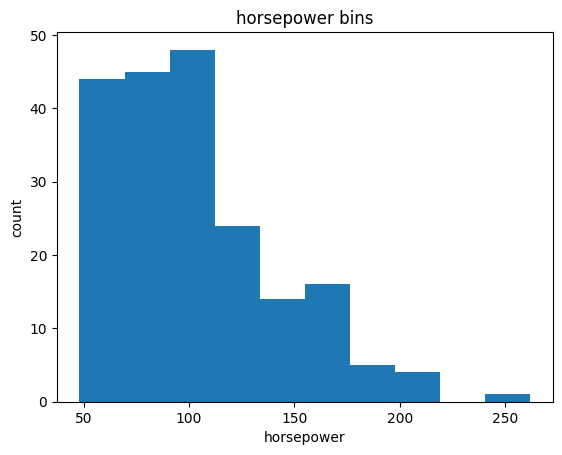

In [44]:
%matplotlib inline

plt.hist(df["horsepower"])

# definir las etiquetas x/y y el título del gráfico
plt.xlabel("horsepower")
plt.ylabel("count")
plt.title("horsepower bins")

<p>Encuentra 3 intervalos de igual amplitud con la función <code>linspace(start_value, end_value, numbers_generated</code> de Numpy.</p>
<p>Como quieres incluir el valor mínimo de horsepower, usa start_value = min(df["horsepower"]).</p>
<p>Como quieres incluir el valor máximo de horsepower, usa end_value = max(df["horsepower"]).</p>
<p>Como construyes 3 intervalos de igual longitud, necesitas 4 divisores, es decir numbers_generated = 4.</p>

Construye un arreglo de intervalos desde el valor mínimo hasta el máximo usando la amplitud calculada arriba. Esos valores determinan dónde termina un intervalo y empieza el siguiente.

In [45]:
bins = np.linspace(min(df["horsepower"]), max(df["horsepower"]), 4)
bins

array([ 48.        , 119.33333333, 190.66666667, 262.        ])

Define los nombres de los grupos:

In [46]:
group_names = ['Low', 'Medium', 'High']

Aplica la función "cut" para determinar a qué intervalo pertenece cada valor de `df['horsepower']`. 

In [47]:
df['horsepower-binned'] = pd.cut(df['horsepower'], bins, labels=group_names, include_lowest=True )
df[['horsepower','horsepower-binned']].head(20)

,horsepower,horsepower-binned
0,111,Low
1,111,Low
2,154,Medium
3,102,Low
4,115,Low
5,110,Low
6,110,Low
7,110,Low
8,140,Medium
9,101,Low


Mira cuántos vehículos hay en cada intervalo:

In [ ]:
df["horsepower-binned"].value_counts()

Grafica la distribución de cada intervalo:

In [ ]:
%matplotlib inline

plt.bar(group_names, df["horsepower-binned"].value_counts().reindex(group_names))

# definir las etiquetas x/y y el título del gráfico
plt.xlabel("horsepower")
plt.ylabel("count")
plt.title("horsepower bins")

<p>
    Observa con atención el dataframe de arriba. Verás que la última columna muestra los intervalos de "horsepower" según 3 categorías ("Low", "Medium" y "High"). 
</p>
<p>
    ¡Lograste reducir los intervalos de 59 a 3!
</p>

<h3>Visualización de los intervalos</h3>
Normalmente se usa un histograma para visualizar la distribución de los intervalos que creamos arriba. 

In [ ]:
%matplotlib inline

# dibujar el histograma del atributo "horsepower" con bins = 3
plt.hist(df["horsepower"], bins=3)

# definir las etiquetas x/y y el título del gráfico
plt.xlabel("horsepower")
plt.ylabel("count")
plt.title("horsepower bins")

El gráfico anterior muestra el resultado del agrupamiento en intervalos del atributo "horsepower". 

## Variable indicadora
<b>¿Qué es una variable indicadora?</b>
<p>
    Una variable indicadora (o variable dummy) es una variable numérica que se usa para etiquetar categorías. Se llaman 'dummies' porque los números en sí mismos no tienen un significado propio. 
</p>

<b>¿Para qué usar variables indicadoras?</b>
<p>
    Se usan para poder emplear variables categóricas en el análisis de regresión en los módulos posteriores.
</p>
<b>Ejemplo</b>
<p>
    La columna "fuel-type" tiene dos valores distintos: "gas" o "diesel". La regresión no entiende palabras, solo números. Para usar este atributo en un análisis de regresión, puedes convertir "fuel-type" en variables indicadoras.
</p>

<p>
    Usa el método 'get_dummies' de Pandas para asignar valores numéricos a las distintas categorías del tipo de combustible. 
</p>

In [ ]:
df.columns

Obtén las variables indicadoras y asígnalas al dataframe "dummy_variable_1":

In [ ]:
dummy_variable_1 = pd.get_dummies(df["fuel-type"], dtype=int)
dummy_variable_1.head()

Cambia los nombres de las columnas para mayor claridad:

In [ ]:
dummy_variable_1.rename(columns={'gas':'fuel-type-gas', 'diesel':'fuel-type-diesel'}, inplace=True)
dummy_variable_1.head()

En el dataframe, la columna 'fuel-type' ahora tiene los valores 'gas' y 'diesel' como 0s y 1s.

In [ ]:
# unir el dataframe "df" con "dummy_variable_1" 
df = pd.concat([df, dummy_variable_1], axis=1)

# eliminar la columna original "fuel-type" de "df"
df.drop("fuel-type", axis = 1, inplace=True)

In [ ]:
df.head()

Las dos últimas columnas son ahora la representación en variables indicadoras de la variable fuel-type. Todas son 0s y 1s.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Pregunta #4: </h1>

<b>De forma similar al ejercicio anterior, crea una variable indicadora para la columna "aspiration"</b>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar

<details><summary>Haz clic aquí para ver la solución</summary>

```python
# obtener las variables indicadoras de aspiration y asignarlas al dataframe "dummy_variable_2"
dummy_variable_2 = pd.get_dummies(df['aspiration'], dtype=int)

# cambiar los nombres de las columnas para mayor claridad
dummy_variable_2.rename(columns={'std':'aspiration-std', 'turbo': 'aspiration-turbo'}, inplace=True)

# mostrar las primeras 5 filas del dataframe "dummy_variable_2"
dummy_variable_2.head()
```

</details>

  <div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Pregunta #5: </h1>

<b>Une el nuevo dataframe al dataframe original y luego elimina la columna 'aspiration'.</b>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar

<details><summary>Haz clic aquí para ver la solución</summary>

```python
# unir el nuevo dataframe al dataframe original
df = pd.concat([df, dummy_variable_2], axis=1)

# eliminar la columna original "aspiration" de "df"
df.drop('aspiration', axis = 1, inplace=True)


```
</details>

Guarda el nuevo csv:

In [ ]:
df.to_csv('clean_df.csv', index=False)

### ¡Gracias por completar este laboratorio!


## Autor

<a href="https://www.linkedin.com/in/joseph-s-50398b136/" target="_blank">Joseph Santarcangelo</a>


### Otros colaboradores

<a href="https://www.linkedin.com/in/mahdi-noorian-58219234/" target="_blank">Mahdi Noorian PhD</a>

Bahare Talayian

Eric Xiao

Steven Dong

Parizad

Hima Vasudevan

<a href="https://www.linkedin.com/in/fiorellawever/" target="_blank">Fiorella Wenver</a>

<a href=" https://www.linkedin.com/in/yi-leng-yao-84451275/ " target="_blank" >Yi Yao</a>.

<a href=" https://www.coursera.org/instructor/~129186572/" target="_blank" >Abhishek Gagneja </a>

## <h3 align="center"> © IBM Corporation 2023. Todos los derechos reservados. <h3/>
<!--
## Change Log


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2023-09-28 | 2.3| Abhishek Gagneja| Instructional Update |
| 2020-10-30  | 2.2  | Lakshmi  |  Changed URL of csv  |
| 2020-09-09  | 2.1  | Lakshmi  |  Updated Indicator Variables section  |
| 2020-08-27  | 2.0  | Lavanya  |  Moved lab to course repo in GitLab  |


--!>

<hr>


